In [1]:
# Importing library
################################################################################

import tensorflow as tf
from tensorflow import config
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers, optimizers, initializers
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.layers import LeakyReLU, BatchNormalization
import numpy as np
import os
import numpy.ma as ma
from sklearn.utils import shuffle
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, Activation, Flatten, MaxPooling2D, AveragePooling2D,Input, Dropout, Multiply, Reshape, Permute

from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from keras.layers import Dense, Dropout, Activation, Flatten
import time
import numpy as np
from tensorflow.keras.initializers import random_normal, random_uniform, glorot_normal, glorot_uniform, HeNormal, HeUniform, Zeros
from sklearn.model_selection import train_test_split
#from google.colab import files
from netCDF4 import Dataset
import math
from tensorflow.keras import regularizers
from scipy import signal
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import grangercausalitytests

2026-03-27 14:39:11.424999: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 14:39:11.441556: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774622351.459964 1865492 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774622351.465765 1865492 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774622351.481052 1865492 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
#!pip install basemap
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
def plot_map(lon,lat,data,file_name):
#     m = Basemap(projection='cyl', resolution='l',
#             llcrnrlat=np.min(lat), urcrnrlat=np.max(lat),
#             llcrnrlon=np.min(lon), urcrnrlon=np.max(lon), )

    m = Basemap(projection='cyl', resolution='l',
            llcrnrlat=np.min(lat_sst), urcrnrlat=np.max(lat_sst),
            llcrnrlon=np.min(lon_sst), urcrnrlon=np.max(lon_sst), )
    #m.drawcoastlines()
    #plt.show()
    lons,lats= np.meshgrid(lon,lat)
    x,y = m(lons,lats)
    
    #m.drawcoastlines()
    levels = np.linspace(min(np.unique(data)),max(np.unique(data)),21)
    #levels = np.linspace(0.0,1.0,21)
    #levels=[-30,-20,-12,-9,-6,-2,-1,+1,+2,+6,+9,+12,+20,+30]
    temp = m.contourf(x,y,data,levels=levels,cmap='seismic')
    cb = m.colorbar(temp,"bottom", size="15%", pad="10%")
    m.drawcoastlines()
    m.drawparallels(np.arange(-90., 91., 30.), labels=[1, 0, 0, 0])
    m.drawmeridians(np.arange(0., 361., 45.), labels=[0, 0, 0, 1])
    #plt.title('sst')
    #cb.set_label('sst')

    plt.savefig(file_name)
    


    plt.show()
    plt.clf()



In [ ]:
data3 = Dataset('18_month_lead/Soda_NDJ_detrend_1979_2009.nc','r')
lat_sst = data3.variables['lat'][:]
lon_sst = data3.variables['lon'][:]

In [4]:
# =============================================================================
# 2D Granger Causality Layer  (runs offline, before model construction)
# =============================================================================

def compute_2d_granger_attention(X, Y,
                                  kernel_size=(8, 4),
                                  stride=(4, 2),
                                  max_lag=3,
                                  softmax_temp=1.0):
    N, lon_size, lat_size, C = X.shape
    Y_flat = Y.reshape(N).astype(np.float64)
    y_norm = (Y_flat - Y_flat.mean()) / (Y_flat.std() + 1e-8)

    kh, kw = kernel_size
    sh, sw = stride

    # Number of valid non-overlapping steps
    lon_out = (lon_size - kh) // sh + 1   # <-- was math.ceil(lon_size/sh)
    lat_out = (lat_size - kw) // sw + 1

    f_map_strided = np.zeros((lon_out, lat_out, C), dtype=np.float32)

    total = lon_out * lat_out * C
    done  = 0

    for c in range(C):
        for i_out in range(lon_out):
            for j_out in range(lat_out):

                # BUG 1 FIX: direct stride offset, no centering
                i_lo = i_out * sh
                i_hi = i_lo + kh
                j_lo = j_out * sw
                j_hi = j_lo + kw

                patch = X[:, i_lo:i_hi, j_lo:j_hi, c]
                patch_ts = patch.reshape(N, -1).mean(axis=1).astype(np.float64)
                if np.isnan(patch_ts).any():
                    print("NaN detected in patch", i_out, j_out, c)
                if patch_ts.std() < 1e-6:
                    done += 1
                    continue

                patch_norm = (patch_ts - patch_ts.mean()) / (patch_ts.std() + 1e-8)
                data = np.column_stack([y_norm, patch_norm])
                exception_count = 0
                try:
                    result = grangercausalitytests(data, maxlag=max_lag, verbose=False)
                    f_vals = [result[lag][0]['ssr_ftest'][0]
                              for lag in range(1, max_lag + 1)]
                    f_map_strided[i_out, j_out, c] = float(np.max(f_vals))
                except Exception as e:
                    f_map_strided[i_out, j_out, c] = 0.0
                    exception_count += 1          # add counter at top: exception_count = 0
                    if exception_count <= 5:
                        print(f"  [EXCEPTION at ({i_out},{j_out},{c})]: {e}")

                done += 1
                if done % 200 == 0:
                    print(f"  {done}/{total} ({100.*done/total:.1f}%) done")

    # Bilinear upsample (unchanged)
    f_map_4d   = f_map_strided[np.newaxis, ...]
    f_map_full = tf.image.resize(f_map_4d, size=(lon_size, lat_size),
                                 method='bilinear').numpy()[0]
    f_score_map = f_map_full.astype(np.float32)

    # BUG 2 FIX: min-max directly on F-scores, no softmax collapse
    attention_map = np.zeros_like(f_score_map)
    for c in range(C):
        raw = f_score_map[:, :, c]
        attention_map[:, :, c] = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)

    return attention_map.astype(np.float32), f_score_map

In [5]:
# =============================================================================
# Keras layer: apply a pre-computed attention map inside the model graph
# =============================================================================

class GrangerAttentionLayer(layers.Layer):
    """
    Keras layer that multiplies its input by a fixed (non-trainable)
    spatial attention map derived from the 2D Granger causality test.

    The map is stored as a non-trainable weight so it is saved with the
    model and correctly restored on load.

    Parameters
    ----------
    attention_map : np.ndarray, shape (lon, lat, C)
        Pre-computed attention weights from compute_2d_granger_attention().
    trainable_map : bool
        If True, allow the attention map to be fine-tuned along with the
        CNN during transfer learning.  Default False (frozen).
    """

    def __init__(self, attention_map, trainable_map=False, **kwargs):
        super().__init__(**kwargs)
        self._init_map   = attention_map.astype(np.float32)
        self._trainable_map = trainable_map

    def build(self, input_shape):
        self.attention = self.add_weight(
            name='granger_attention_map',
            shape=self._init_map.shape,
            initializer=tf.constant_initializer(self._init_map),
            trainable=self._trainable_map
        )
        super().build(input_shape)

    def call(self, x):
        # x shape: (batch, lon, lat, C)
        # attention shape: (lon, lat, C)  — broadcast over batch
        return x * self.attention

    def get_config(self):
        config = super().get_config()
        config.update({
            'attention_map':  self._init_map.tolist(),
            'trainable_map':  self._trainable_map
        })
        return config

    @classmethod
    def from_config(cls, config):
        config['attention_map'] = np.array(config['attention_map'],
                                            dtype=np.float32)
        return cls(**config)


In [6]:
# =============================================================================
# Model builder
# =============================================================================

def build_granger_cnn(input_shape, attention_map,
                       num_convf=32, num_hiddf1=128,
                       trainable_attention=False):
    """
    Build the Granger-attention CNN.

    Parameters
    ----------
    input_shape : tuple
        (lon, lat, C) — e.g. (144, 48, 3).
    attention_map : np.ndarray, shape matching input_shape
        Output of compute_2d_granger_attention().
    num_convf : int
        Number of Conv2D filters per layer.
    num_hiddf1 : int
        Dense hidden layer width.
    trainable_attention : bool
        Whether to allow the Granger map to be updated during training.
        Keep False for base CMIP6 training; optionally True for fine-tuning.

    Returns
    -------
    model : tf.keras.Model
    """

    weight = tf.initializers.RandomNormal(stddev=0.1)
    bias   = tf.initializers.RandomUniform(minval=-0.01, maxval=0.01)

    inputs = Input(shape=input_shape, name='input_field')

    # ── 2D Granger attention ──────────────────────────────────────────────
    x = GrangerAttentionLayer(
        attention_map,
        trainable_map=trainable_attention,
        name='granger_attention'
    )(inputs)

    # ── CNN backbone (identical to original structure) ────────────────────
    x = Conv2D(num_convf, (8, 4), strides=(1, 1),
               kernel_initializer=weight, bias_initializer=bias,
               padding='same', name='conv1')(x)
    x = LeakyReLU(name='lrelu1')(x)
    x = BatchNormalization(name='bn1')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2),
                     padding='same', name='pool1')(x)
    x = Dropout(0.5, name='drop1')(x)

    x = Conv2D(num_convf, (4, 2), strides=(1, 1),
               kernel_initializer=weight, bias_initializer=bias,
               padding='same', name='conv2')(x)
    x = LeakyReLU(name='lrelu2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2),
                     padding='same', name='pool2')(x)
    x = Dropout(0.5, name='drop2')(x)

    x = Conv2D(num_convf, (4, 2), strides=(1, 1),
               kernel_initializer=weight, bias_initializer=bias,
               padding='same', name='conv3')(x)
    x = LeakyReLU(name='lrelu3')(x)
    x = BatchNormalization(name='bn3')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2),
                     padding='same', name='pool3')(x)
    x = Dropout(0.5, name='drop3')(x)

    x = Conv2D(num_convf, (2, 2), strides=(1, 1),
               kernel_initializer=weight, bias_initializer=bias,
               padding='same', name='conv4')(x)
    x = LeakyReLU(name='lrelu4')(x)
    x = BatchNormalization(name='bn4')(x)
    x = Dropout(0.5, name='drop4')(x)

    x = Flatten(name='flatten')(x)

    x = Dense(num_hiddf1,
              kernel_initializer=weight, bias_initializer=bias,
              name='dense1')(x)
    x = LeakyReLU(name='lrelu5')(x)
    x = Dropout(0, name='drop5')(x)

    outputs = Dense(1,
                    kernel_initializer=weight, bias_initializer=bias,
                    name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='granger_cnn')
    return model

In [ ]:
# Loading CMIP6 training data
###############################################################################

trX=np.load('18_month_lead/CMIP6_MME_Input.npy', allow_pickle=True)
trY=np.load('18_month_lead/CMIP6_MME_Output_yearmean.npy', allow_pickle=True)

trX=np.swapaxes(trX, 1, 2)

arr=[]
for i in range(6390):
    input_file=np.zeros((3,48,144), dtype=np.float32)
    input_file[0,:,:]=np.flipud(trX[i,:,:,0])
    input_file[1,:,:]=np.flipud(trX[i,:,:,1])
    input_file[2,:,:]=np.flipud(trX[i,:,:,2])
    
    arr.append(input_file)

trX=np.array(arr)
trX=np.swapaxes(trX,1,3)


trainX, trainY = shuffle(trX, trY, random_state=2)

In [8]:
trX.shape

(6390, 144, 48, 3)

In [ ]:

input_shape = (144, 48, 3)






print("Computing 2D Granger attention map (this runs once)...")
attention_map, f_score_map = compute_2d_granger_attention(
    trX, trY,
    kernel_size=(16, 8),
    stride=(1, 1),
    max_lag=1,
    softmax_temp=0.8   # <1 sharpens attention on most causal regions
)

# Save the map so you never have to recompute it
np.save('granger_attention_map.npy', attention_map)
np.save('granger_f_score_map.npy',   f_score_map)
print("Attention maps saved.")

Computing 2D Granger attention map (this runs once)...


/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


  200/15867 (1.3%) done
  400/15867 (2.5%) done
  600/15867 (3.8%) done
  800/15867 (5.0%) done
  1000/15867 (6.3%) done
  1200/15867 (7.6%) done
  1400/15867 (8.8%) done
  1600/15867 (10.1%) done
  1800/15867 (11.3%) done
  2000/15867 (12.6%) done
  2200/15867 (13.9%) done
  2400/15867 (15.1%) done
  2600/15867 (16.4%) done
  2800/15867 (17.6%) done
  3000/15867 (18.9%) done
  3200/15867 (20.2%) done
  3400/15867 (21.4%) done
  3600/15867 (22.7%) done
  3800/15867 (23.9%) done
  4000/15867 (25.2%) done
  4200/15867 (26.5%) done
  4400/15867 (27.7%) done
  4600/15867 (29.0%) done
  4800/15867 (30.3%) done
  5000/15867 (31.5%) done
  5200/15867 (32.8%) done
  5400/15867 (34.0%) done
  5600/15867 (35.3%) done
  5800/15867 (36.6%) done
  6000/15867 (37.8%) done
  6200/15867 (39.1%) done
  6400/15867 (40.3%) done
  6600/15867 (41.6%) done
  6800/15867 (42.9%) done
  7000/15867 (44.1%) done
  7200/15867 (45.4%) done
  7400/15867 (46.6%) done
  7600/15867 (47.9%) done
  7800/15867 (49.2%) do

W0000 00:00:1774622567.662278 1865492 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [10]:
# # ── Step 1: Sanity check your raw outputs ──────────────────────────────────
# print("=== f_score_map stats ===")
# print(f"  shape : {f_score_map.shape}")
# print(f"  min   : {f_score_map.min():.6f}")
# print(f"  max   : {f_score_map.max():.6f}")
# print(f"  mean  : {f_score_map.mean():.6f}")
# print(f"  nonzero: {np.count_nonzero(f_score_map)} / {f_score_map.size}")

# print("\n=== attention_map stats ===")
# print(f"  min   : {attention_map.min():.8f}")
# print(f"  max   : {attention_map.max():.8f}")
# print(f"  unique values (first 10): {np.unique(attention_map.ravel())[:10]}")

# print("\n=== trX / trY stats ===")
# print(f"  trX shape : {trX.shape}")
# print(f"  trX std   : {trX.std():.4f}")
# print(f"  trX has NaN: {np.isnan(trX).any()}")
# print(f"  trY shape : {trY.shape}")
# print(f"  trY std   : {trY.std():.4f}")
# print(f"  trY has NaN: {np.isnan(trY).any()}")

In [11]:
def plot_attention_map(attention_map_path='granger_attention_map.npy'):
    """
    Quick visualisation of the saved Granger attention map.
    Requires matplotlib and cartopy (optional).
    """
    import matplotlib.pyplot as plt

    amap = np.load(attention_map_path)          # (144, 48, 3)
    channel_names = ['N',
                     'D',
                     'J']

    #fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for c in range(3):
        # im = ax.imshow(amap[:, :, c].T,
        #                origin='lower',
        #                aspect='auto',
        #                cmap='YlOrRd',
        #                interpolation='bilinear')
        # ax.set_title(channel_names[c])
        # ax.set_xlabel('Longitude index')
        # ax.set_ylabel('Latitude index')
        # plt.colorbar(im, ax=ax, label='Attention weight')
        plot_map(lon_sst, lat_sst, np.flipud(amap[:, :, c].T),
                 file_name=f'granger_attention_map_{channel_names[c]}.png')
        plt.show()

    # plt.suptitle('2D Granger causality attention map  '
    #              '(warmer = more causal for ISMR)', y=1.02)
    # plt.tight_layout()
    # plt.savefig('granger_attention_map.png', dpi=150, bbox_inches='tight')
    
    print("Saved: granger_attention_map.png")


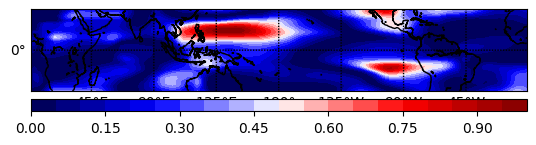

<Figure size 640x480 with 0 Axes>

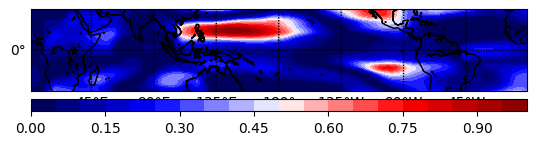

<Figure size 640x480 with 0 Axes>

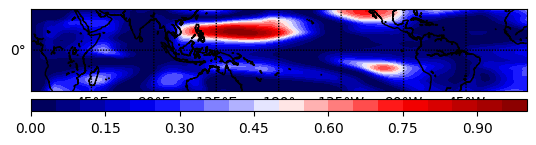

<Figure size 640x480 with 0 Axes>

Saved: granger_attention_map.png


In [15]:
plot_attention_map(attention_map_path='granger_attention_map.npy')

In [16]:
input_shape = (144, 48, 3)
attention_map = np.load('granger_attention_map.npy')
# ── 3. Build model ────────────────────────────────────────────────────
model = build_granger_cnn(
    input_shape=input_shape,
    attention_map=attention_map,
    num_convf=32,
    num_hiddf1=128,
    trainable_attention=True   # freeze Granger map during CNN training
)
model.summary()

Model: "granger_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_field (InputLayer)        │ (None, 144, 48, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ granger_attention               │ (None, 144, 48, 3)     │        20,736 │
│ (GrangerAttentionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 144, 48, 32)    │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu1 (LeakyReLU)              │ (None, 144, 48, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 144, 48, 32)    │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 72, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 72, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 72, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu2 (LeakyReLU)              │ (None, 72, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 72, 24, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 36, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 36, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 36, 12, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu3 (LeakyReLU)              │ (None, 36, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 36, 12, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 18, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 18, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 18, 6, 32)      │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu4 (LeakyReLU)              │ (None, 18, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 18, 6, 32)      │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 18, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3456)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       442,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu5 (LeakyReLU)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 487,553 (1.86 MB)

 Trainable params: 487,297 (1.86 MB)

 Non-trainable params: 256 (1.00 KB)

In [18]:
model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='mean_squared_error')

In [ ]:
# load weights from Sharma et. al. 2026 paper and assign the weights to the new model (except the attention layer)
m = keras.models.load_model('18-month_lead/Sample_Model.hdf5')
m.load_weights('CNN_weights/18-month/fine_tune_1.hdf5')
model.weights[1:]=m.weights

In [20]:
# ── 4. Train on CMIP6 ────────────────────────────────────────────────
mc = keras.callbacks.ModelCheckpoint(
    '{epoch:08d}.weights.h5',
    save_weights_only=True,
    save_freq=100
)
model.fit(trainX, trainY,
            epochs=1000,
            batch_size=400,
            callbacks=[mc])

model.save('Sample_Model_Granger.keras')

Epoch 1/1000


E0000 00:00:1774622609.935147 1865492 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/granger_cnn_1/lrelu2_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/granger_cnn_1/conv2_1/BiasAdd'.


16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 804ms/step - loss: 31.3057
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 757ms/step - loss: 12.3078
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 758ms/step - loss: 6.3693
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 747ms/step - loss: 3.8659
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 743ms/step - loss: 2.9169
Epoch 6/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 746ms/step - loss: 2.3068
Epoch 7/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 755ms/step - loss: 1.9299
Epoch 8/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 746ms/step - loss: 1.7544
Epoch 9/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 744ms/step - loss: 1.4661
Epoch 10/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 751ms/step - loss: 1.4362
Epoch 11/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 747ms/step - loss: 1.3078
Epoch 12/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 746ms/step - loss: 1.2031
Epoch 13/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 742ms/step - loss: 1.0985
Epoch 14/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 746ms/step - loss: 1.0730
Epoch 15/1000
16/16 ━━━━━━

In [21]:
model.save('Sample_Model_Granger.keras')

In [ ]:
# Loading transfer learning dataset
#############################################################################################

data1=Dataset('18_month_lead/Soda_NDJ_detrend_transfer_1871_1974.nc', 'r')
trX_soda=data1.variables['d20'][:]

trX=[]
for i in range(0,312,3):
    input_file=np.zeros((3,48,144), dtype=np.float32)
    input_file[0,:,:]=np.flipud(trX_soda[i,:,:])
    input_file[1,:,:]=np.flipud(trX_soda[i+1,:,:])
    input_file[2,:,:]=np.flipud(trX_soda[i+2,:,:])
    
    trX.append(input_file)

trX=np.array(trX)
trX=np.swapaxes(trX,1,3)
trX=ma.masked_values(trX, -9.99e+08)

index_1=[]
for i in range(104):
    index_2=[]
    for j in range(144):
        index_3=[]
        for k in range(48):
            index_4=[]
            for l in range(3):
                val=trX[i,j,k,l]
                if math.isnan(val)==False:
                    index_4.append(val)
                else:
                    index_4.append(0)
            index_3.append(index_4)
        index_2.append(index_3)
    index_1.append(index_2)
trX=np.array(index_1)


data2=Dataset('18_month_lead/JJAS_detrend_transfer_1873_1976.nc','r')
trY=data2.variables['var1'][:]

trY=trY.reshape(104,1)

/tmp/ipykernel_1865492/2987230363.py:29: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(val)==False:


In [ ]:
# Loading validation dataset
#############################################################################################

data3=Dataset('18_month_lead/Soda_NDJ_detrend_1979_2009.nc','r')
teX_soda=data3.variables['d20'][:]

teX=[]
for i in range(0,93,3):
    input_file=np.zeros((3,48,144), dtype=np.float32)
    input_file[0,:,:]=np.flipud(teX_soda[i,:,:])
    input_file[1,:,:]=np.flipud(teX_soda[i+1,:,:])
    input_file[2,:,:]=np.flipud(teX_soda[i+2,:,:])
    
    teX.append(input_file)

teX=np.array(teX)
teX=np.swapaxes(teX,1,3)
teX=ma.masked_values(teX, -9.99e+08)

index_1=[]
for i in range(31):
    index_2=[]
    for j in range(144):
        index_3=[]
        for k in range(48):
            index_4=[]
            for l in range(3):
                val=teX[i,j,k,l]
                if math.isnan(val)==False:
                    index_4.append(val)
                else:
                    index_4.append(0)
            index_3.append(index_4)
        index_2.append(index_3)
    index_1.append(index_2)
teX=np.array(index_1)


data4=Dataset('18_month_lead/JJAS_detrend_1981_2011.nc','r')
teY=data4.variables['var1'][:]

teY=teY.reshape(31,1)

trainX, trainY = shuffle(trX, trY, random_state=2)


/tmp/ipykernel_1865492/4033072642.py:29: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(val)==False:


In [24]:
# Selecting the best base model
###############################################################################

#fine_tune=keras.models.load_model('Sample_Model_Granger.keras')

fine_tune = keras.models.load_model(
    'Sample_Model_Granger.keras',
    custom_objects={'GrangerAttentionLayer': GrangerAttentionLayer}
)

for i in range(9):
  fine_tune.load_weights('00000'+str(i+1)+'00.weights.h5')

  from scipy.stats import pearsonr

  prediction=fine_tune.predict(teX)
  prediction=prediction.reshape(31,)

  teY=teY.reshape(31,)
  corr, p = pearsonr(prediction, teY) 
  print('weight', i+1)
  print('corr', corr)
  print('p value', p)
  print('STD', np.std(prediction))

# fine_tune.load_weights('00001000.weights.h5')

# from scipy.stats import pearsonr

# prediction=fine_tune.predict(teX)
# prediction=prediction.reshape(31,)

# teY=teY.reshape(31,)
# corr, p = pearsonr(prediction, teY) 
# print('weight', 10)
# print('corr', corr)
# print('p value', p)
# print('STD', np.std(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
weight 1
corr 0.1601543548255569
p value 0.3894403126446347
STD 0.09391633
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
weight 2
corr 0.11409194810483145
p value 0.5411112882726672
STD 0.13177375
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
weight 3
corr 0.27089605123863597
p value 0.14047450001952402
STD 0.15740724
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
weight 4
corr 0.21679392758848032
p value 0.24141771563903228
STD 0.22316317
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
weight 5
corr 0.09163299330538331
p value 0.6239509144717051
STD 0.53751075
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
weight 6
corr 0.006918868230860319
p value 0.9705329001507452
STD 0.64037776
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
weight 7
corr 0.02657631022506185
p value 0.8871473686194634
STD 0.6600777
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
weight 8
corr 0.09414042458049202
p value 0.6144488580424656
STD 0.6199904
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
weight 9
corr 0.06824659886266445
p value 0.71526

In [34]:
# Fine tuning the best base model
###############################################################################

input_shape = (144, 48, 3)
attention_map = np.load('granger_attention_map.npy')
# ── 3. Build model ────────────────────────────────────────────────────
fine_tune = build_granger_cnn(
    input_shape=input_shape,
    attention_map=attention_map,
    num_convf=32,
    num_hiddf1=128,
    trainable_attention=True   # freeze Granger map during CNN training
)


# fine_tune = keras.models.load_model(
#     'Sample_Model_Granger.keras',
#     custom_objects={'GrangerAttentionLayer': GrangerAttentionLayer}
# )

#fine_tune=keras.models.load_model('Sample_Model.keras')
fine_tune.load_weights('00000300.weights.h5')

opt=Adam(learning_rate=0.000005)

fine_tune.compile(optimizer=opt, loss='mean_squared_error')
model_checkpoint_callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10, verbose=1,
                                                              mode='min', restore_best_weights=True)

fine_tune.fit(trainX, trainY, epochs=60, batch_size=20)


Epoch 1/60
1/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.5407

E0000 00:00:1774636533.912608 1865492 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/granger_cnn_1/lrelu4_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/granger_cnn_1/conv4_1/BiasAdd'.


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.5753
Epoch 2/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.6434
Epoch 3/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.5901
Epoch 4/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.6246
Epoch 5/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.5819
Epoch 6/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.5501
Epoch 7/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.5478
Epoch 8/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5022
Epoch 9/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5789
Epoch 10/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5353
Epoch 11/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.4427
Epoch 12/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5586
Epoch 13/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.4885
Epoch 14/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.6274
Epoch 15/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5734
Epoch 16/60
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/

In [31]:
# Saving the final CNN model
################################################################################

fine_tune.save_weights('fine_tune.weights.h5')

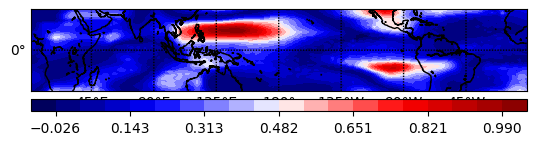

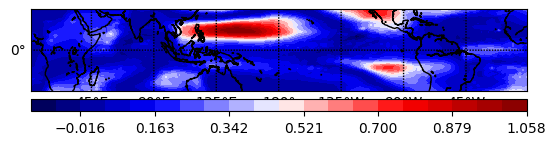

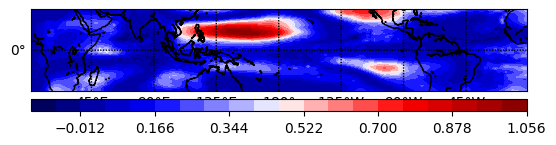

<Figure size 640x480 with 0 Axes>

In [35]:
#access the weights using fine_tune.get_weights() or fine_tune.layers[i].get_weights()
final_attention_map = np.array(fine_tune.layers[1].get_weights()).squeeze()
#plot the final attention map
plot_map(lon_sst, lat_sst, np.flipud(final_attention_map[:, :, 0].T),
         file_name=f'final_attention_map_N.png')
plot_map(lon_sst, lat_sst, np.flipud(final_attention_map[:, :, 1].T),
         file_name=f'final_attention_map_D.png')
plot_map(lon_sst, lat_sst, np.flipud(final_attention_map[:, :, 2].T),
         file_name=f'final_attention_map_J.png')

In [36]:
# Validation of the FInal CNN model
################################################################################

fine_tune.load_weights('fine_tune.weights.h5')

prediction=fine_tune.predict(teX)
prediction=prediction.reshape(31,)

teY=teY.reshape(31,)
corr, p = pearsonr(prediction, teY) 

print('corr', corr)
print('p value', p)
print('STD', np.std(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
corr 0.14225352557861812
p value 0.4452363589859759
STD 0.2028317


In [ ]:
# loading validation data
#################################################################################

data5=Dataset('18_month_lead/Soda_NDJ_detrend_1979_2009.nc', 'r')
teX_soda=data5.variables['d20'][:]

teX=[]
for i in range(0,93,3):
    input_file=np.zeros((3,48,144), dtype=np.float32)
    input_file[0,:,:]=np.flipud(teX_soda[i,:,:])
    input_file[1,:,:]=np.flipud(teX_soda[i+1,:,:])
    input_file[2,:,:]=np.flipud(teX_soda[i+2,:,:])
    
    teX.append(input_file)

teX=np.array(teX)
teX=np.swapaxes(teX,1,3)
teX=ma.masked_values(teX, -9.99e+08)

index_1=[]
for i in range(31):
    index_2=[]
    for j in range(144):
        index_3=[]
        for k in range(48):
            index_4=[]
            for l in range(3):
                val=teX[i,j,k,l]
                if math.isnan(val)==False:
                    index_4.append(val)
                else:
                    index_4.append(0)
            index_3.append(index_4)
        index_2.append(index_3)
    index_1.append(index_2)
teX=np.array(index_1)

data5=Dataset('18_month_lead/ORAS5_NDJ_detrend_2010_2021.nc', 'r')
teX_ORAS5=data5.variables['t20d'][:]

teX_ORA=[]
for i in range(0,36,3):
    input_file=np.zeros((3,48,144), dtype=np.float32)
    input_file[0,:,:]=np.flipud(teX_ORAS5[i,:,:])
    input_file[1,:,:]=np.flipud(teX_ORAS5[i+1,:,:])
    input_file[2,:,:]=np.flipud(teX_ORAS5[i+2,:,:])
    
    teX_ORA.append(input_file)

teX_ORA=np.array(teX_ORA)
teX_ORA=np.swapaxes(teX_ORA,1,3)

data6=Dataset('18_month_lead/IMD_1981_2023.nc','r')
teY=data6.variables['var1'][:]

teY=teY.reshape(43,)

/tmp/ipykernel_1865492/299833100.py:29: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(val)==False:


In [38]:
# testing the final CNN model
####################################################################################
Ensemble_combine=np.zeros((43), dtype=np.float32)
# fine_tune = keras.models.load_model(
#     'Sample_Model_Granger.keras',
#     custom_objects={'GrangerAttentionLayer': GrangerAttentionLayer}
# )
# fine_tune.load_weights('fine_tune.weights.h5')

#Ensemble=np.zeros((31), dtype=np.float32)


    
    
prediction=fine_tune.predict(teX)
prediction=prediction.reshape(31,)


Ensemble_combine[0:31]=prediction

# Extending the forecast to recent period (2012-2023) using ORAS5 D20 dataset





prediction=fine_tune.predict(teX_ORA)
prediction=prediction.reshape(12,)



Ensemble_combine[31:]=prediction

# Normalizing the results
################################################################################

Ensemble_anom=(Ensemble_combine-np.mean(Ensemble_combine))
Ensemble_detrend=signal.detrend(Ensemble_anom)
Ensemble_norm=Ensemble_detrend/np.std(Ensemble_detrend)
Ensemble_norm=Ensemble_norm.reshape(43,)

teY=teY/122
teY_anom=(teY-np.mean(teY))
teY_detrend=signal.detrend(teY_anom)
teY_norm=teY_detrend/np.std(teY_detrend)
teY_norm=teY_norm.reshape(43,)

corr, p = pearsonr(teY_norm, Ensemble_norm)

print('Forecast Skill = ', corr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Forecast Skill =  0.07041085319513668
